## Install the required libraries using pip install
1) torch 
2) torchvision 
3) torchaudio
4) transformers

Install in the same order. transformer library has dependency on the first 3 libraries.

## Sample classifier - Sentiment analysis from transformer library

In [1]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier(
    [
        "I enjoy learning Gen AI for office use.",
        "But I dont have anything installed on my laptop",
    ]
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/home/arun/.virtualenvs/hug/lib/python3.12/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


[{'label': 'POSITIVE', 'score': 0.9986242055892944},
 {'label': 'NEGATIVE', 'score': 0.9942013621330261}]

## Procesing flow

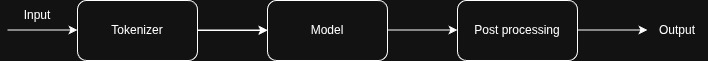



### Below code explains how tokenizing is done
- Model name: DistilBERT base uncased finetuned SST-2 
- Model Description: This model is a fine-tune checkpoint of DistilBERT-base-uncased, fine-tuned on SST-2. This model reaches an accuracy of 91.3 on the dev set (for comparison, Bert bert-base-uncased version reaches an accuracy of 92.7).
    Developed by: Hugging Face
    Model Type: Text Classification
    Language(s): English

AutoTokenizer.from_pretrained will fetch the tokenizer details of the model. 
This is important as tokenizer will be different for different models

In [6]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# Input
raw_inputs = [
    "I enjoy learning Gen AI.",
    "But I dont have anything installed on my laptop",
]
inputs = tokenizer(raw_inputs, padding=True, truncation=True, return_tensors="pt")

# Print each component on separate lines
for key, value in inputs.items():
    print(f"{key}:")
    print(value)
    print()

input_ids:
tensor([[  101,  1045,  5959,  4083,  8991,  9932,  1012,   102,     0,     0,
             0,     0],
        [  101,  2021,  1045,  2123,  2102,  2031,  2505,  5361,  2006,  2026,
         12191,   102]])

token_type_ids:
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

attention_mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])



**token_type_ids:** Each token is assigned an ID indicating which sequence it belongs to. 
For example, in a two-sentence input, all tokens from the first sentence might get 0, and all tokens from the second sentence get 1. In your current example, since you have two distinct sentences but they are processed as independent sequences for simple tokenization (not a pair), they both receive 0s in their respective token_type_ids rows.

**attention_mask:** This is a tensor that indicates which tokens should be attended to by the model and which should be ignored. It's crucial for handling variable-length sequences when they are padded to a common length.
1 indicated that token should be processed 
0 indicates padding token and should be ignored

**Why there are 12 input ids?**
**Tokenization:** The tokenizer converts sentences into a sequence of numerical IDs, where each ID represents a word or subword unit (token). It also adds special tokens like [CLS] (101) at the beginning and [SEP] (102) at the end of each sentence.
**Padding (padding=True):** This argument tells the tokenizer to make all sequences in the batch the same length. It does this by adding 0s (padding tokens) to the end of shorter sequences until they match the length of the longest sequence in the batch or a specified max_length.
**Truncation (truncation=True):** This argument tells the tokenizer to cut off (truncate) sequences that are longer than a specified max_length or the maximum length the model can handle.

The first sentence, "I enjoy learning Gen AI.", tokenizes to 8 tokens (including [CLS] and [SEP]).
The second sentence, "But I dont have anything installed on my laptop", tokenizes to 12 tokens (including [CLS] and [SEP]).

## Download the model to use

**AutoModel**

Raw outputs: Outputs hidden states or features from the final layer.

No task head: Does not include a classification or pooling layer.

Use case: Feature extraction, custom model architectures, or non-standard tasks.


In [7]:
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModel.from_pretrained(checkpoint)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
outputs = model(**inputs)
print(outputs.last_hidden_state.shape)

torch.Size([2, 12, 768])


**outputs = model**(**inputs):** This line passes your tokenized input (inputs) to the distilbert model. The **inputs unpacks the dictionary into keyword arguments expected by the model

**outputs.last_hidden_state**: When you pass inputs through a transformer model like DistilBERT, the model processes these tokenized inputs through its layers. The last_hidden_state attribute of the outputs object gives you the contextualized embeddings for each token in your input sequences, generated by the final layer of the model.

**.shape:**: Returns the dimension of the output

**Batch size: 2**

**Max length of batch or token: 12**

**Embedding size: 768**


## Model for classification


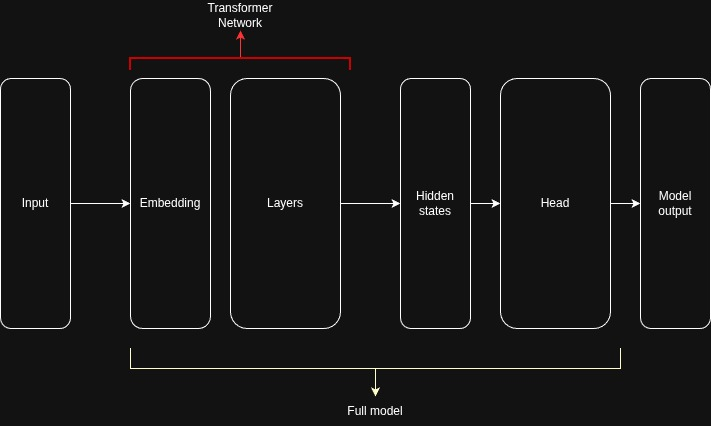



**AutoModelForSequenceClassification**

Task-ready: Includes a linear classification head on top of the base model.

Configurable: Automatically reads num_labels from the model config to size the output layer correctly.

Use case: Standard text classification tasks like sentiment analysis or spam detection.

**Base Model (e.g., DistilBERT):** 

This part of the model is pre-trained on a massive amount of text data (e.g., internet text, books) using self-supervised objectives (like predicting masked words). Its purpose is to learn general language understanding, grammar, syntax, and semantics. When AutoModel is loaded like before model = AutoModel.from_pretrained(checkpoint), it is essentially loading this base body that provides last_hidden_state (the contextual embeddings).

**Model Head:** 

This is a smaller, task-specific neural network attached to the output of the base model. Its job is to take the rich, contextualized embeddings generated by the base model and transform them into an output format suitable for the target task.

There are other model head like  \
*ForCausalLM \
*ForMaskedLM  \
*ForMultipleChoice  \
*ForQuestionAnswering  \
*ForSequenceClassification  \
*ForTokenClassification  



In [10]:
from transformers import AutoModelForSequenceClassification
checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
outputs = model(**inputs)
print(outputs.logits.shape)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

torch.Size([2, 2])


### Output predicted by model for the two lines

Row number 1 is for the first line and 2 for the second line  \
This is then passed through a softmax function to get the probability values.

In [11]:
print(outputs.logits)

tensor([[-3.5674,  3.7576],
        [ 2.8039, -2.3404]], grad_fn=<AddmmBackward0>)


### Model prediction

Now we can see that the model predicted [0.0006584, 0.9934] for the first sentence and [0.9942, 0.00579] for the second one. These are recognizable probability scores.


In [12]:
import torch

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions)

tensor([[6.5843e-04, 9.9934e-01],
        [9.9420e-01, 5.7986e-03]], grad_fn=<SoftmaxBackward0>)


**To get the labels corresponding to each position, we can inspect the id2label attribute of the model config**

In [13]:
model.config.id2label

{0: 'NEGATIVE', 1: 'POSITIVE'}

**This indicates that the first line has a positive tone and second one ha a negative tone**